# Ucitavanje i eksplorativna analiza podataka

In [307]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline

from imblearn.over_sampling import RandomOverSampler

from sklearn.ensemble import RandomForestClassifier

In [308]:
data = pd.read_csv('online_shoppers_intention.csv')
data['Revenue'] = data['Revenue'].map({True: 1, False: 0})

X = data.drop(['Revenue'], axis=1)
# y = data['Revenue'].map({True: 1, False: 0})
y = data['Revenue']

In [309]:
y

0        0
1        0
2        0
3        0
4        0
        ..
12325    0
12326    0
12327    0
12328    0
12329    0
Name: Revenue, Length: 12330, dtype: int64

In [310]:
data.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


In [311]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [312]:
data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [313]:
cat_cols = ['OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Month',
]

num_cols = ['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Revenue'
]

In [314]:
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [315]:
data[cat_cols].nunique()

OperatingSystems     8
Browser             13
Region               9
TrafficType         20
VisitorType          3
Weekend              2
Month               10
dtype: int64

In [316]:
data['Revenue'].value_counts(normalize=True)

Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64

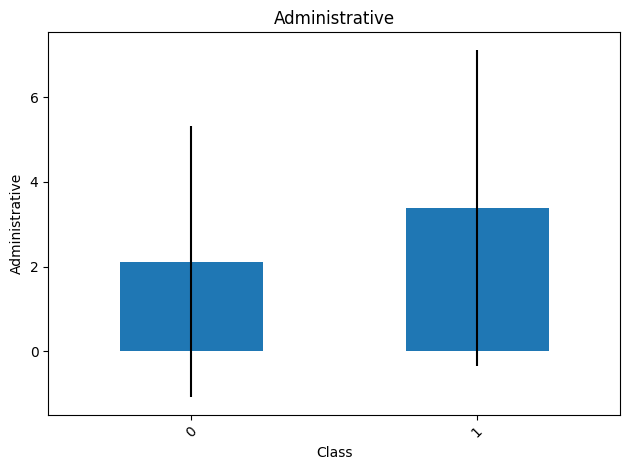

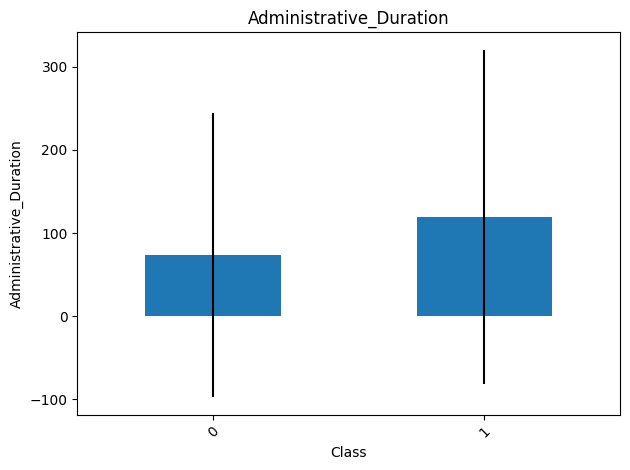

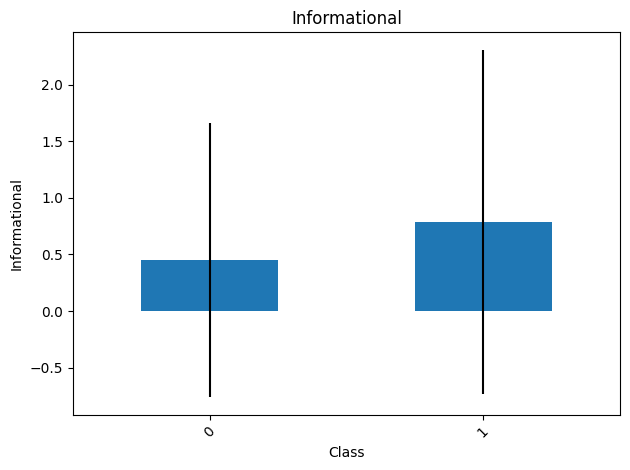

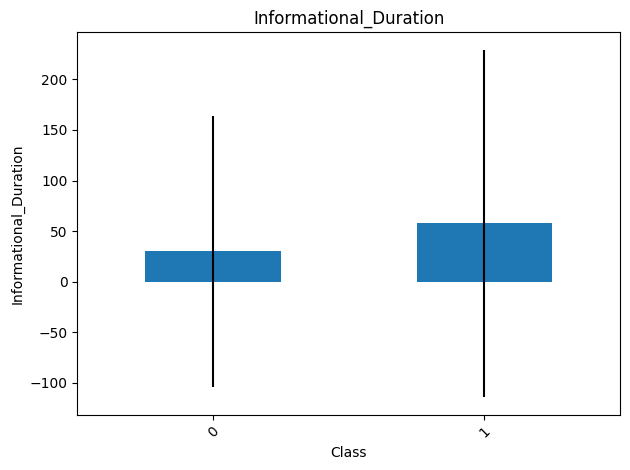

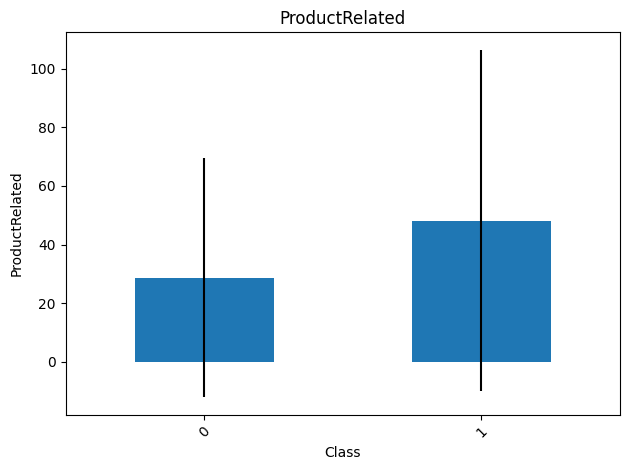

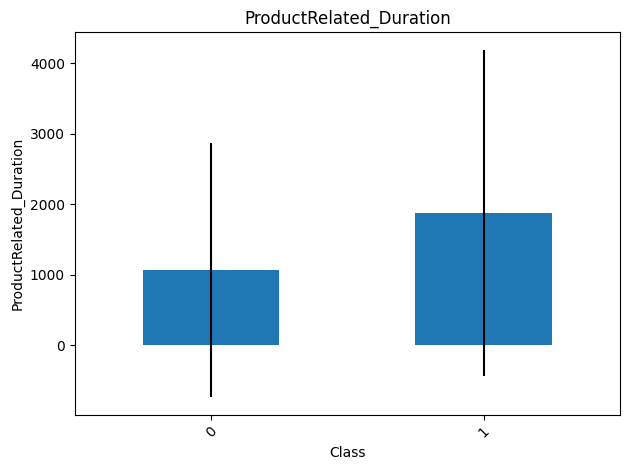

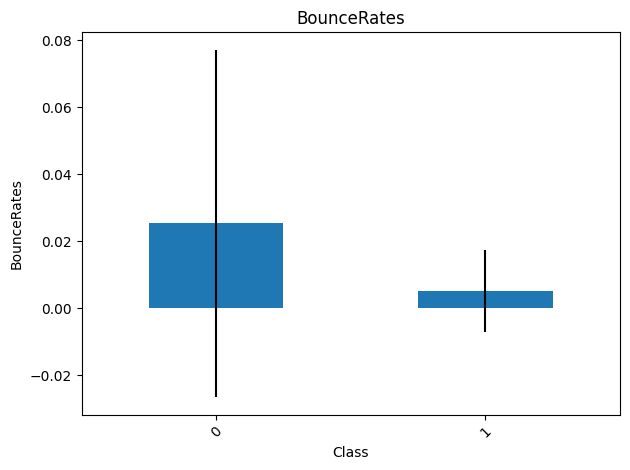

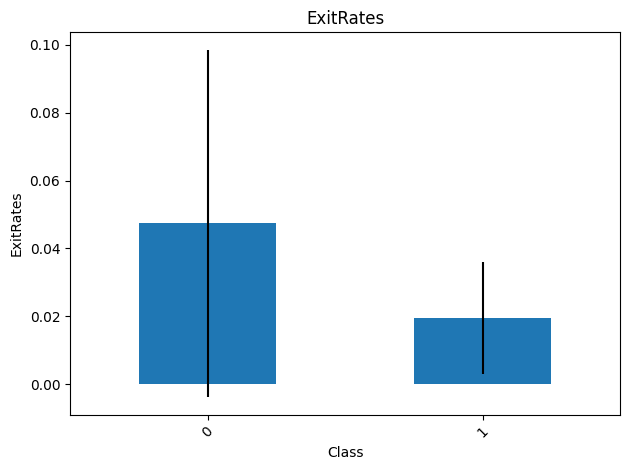

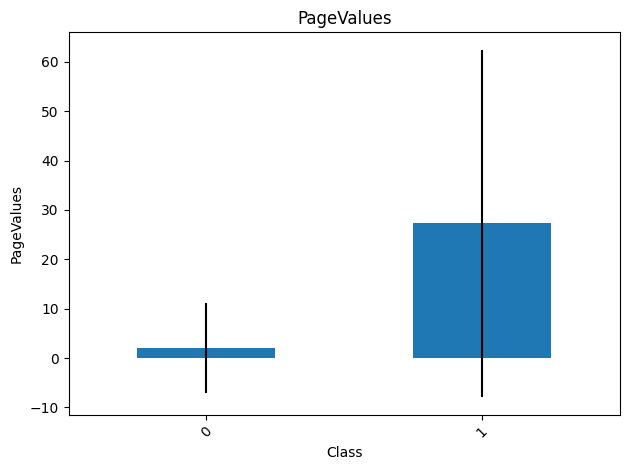

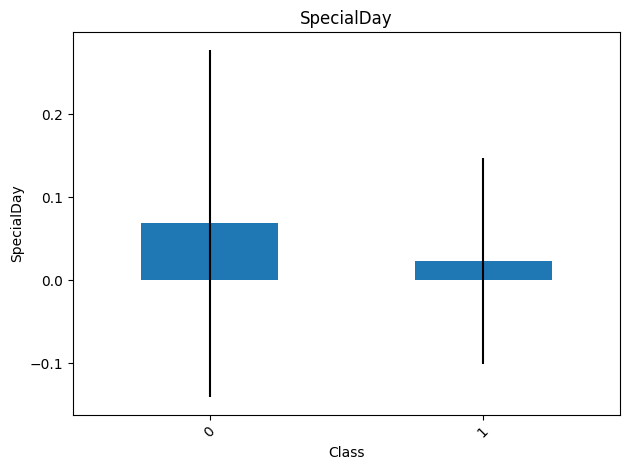

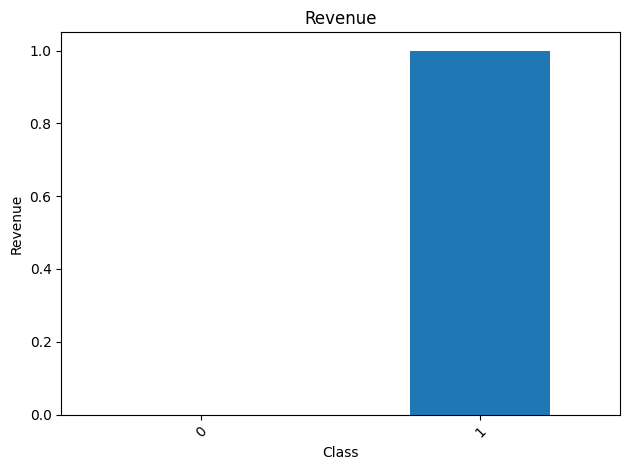

In [317]:
grouped = data.groupby('Revenue')[num_cols]

means = grouped.mean()
stds = grouped.std()

for col in num_cols:
    plt.figure()
    
    means[col].plot(
        kind='bar',
        yerr=stds[col],
    )
    
    plt.title(f'{col}')
    plt.xlabel('Class')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

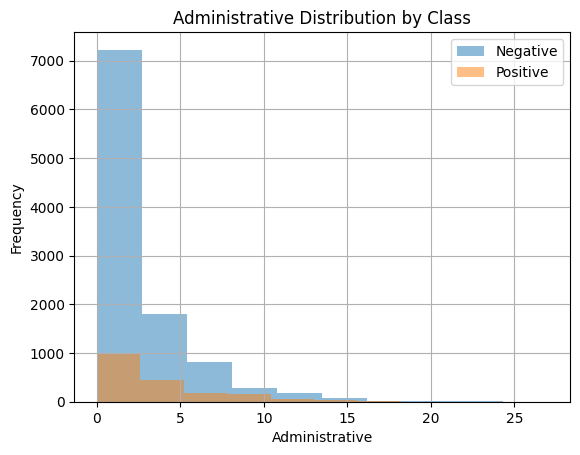

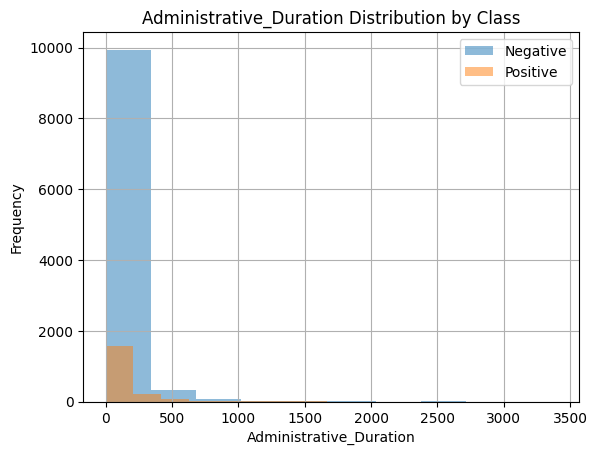

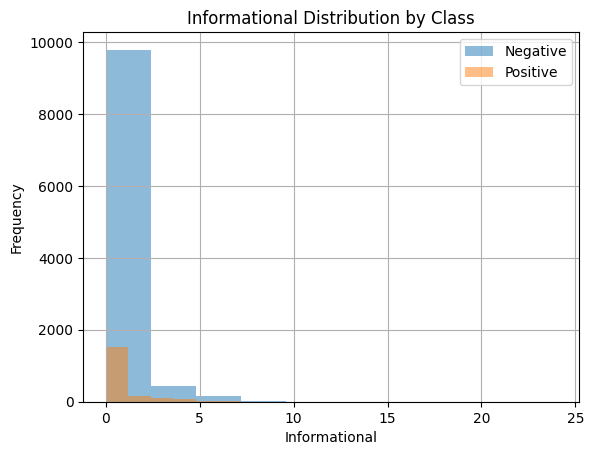

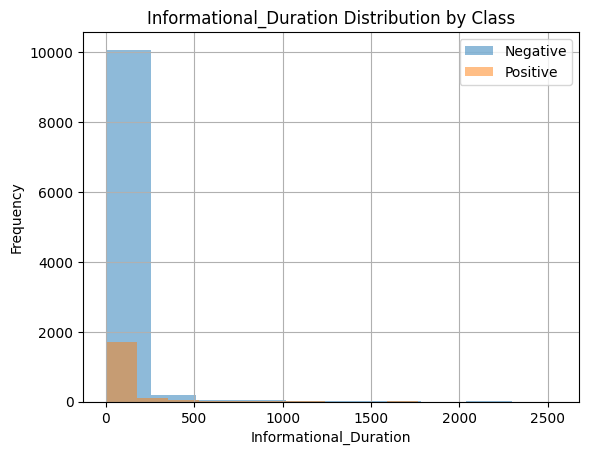

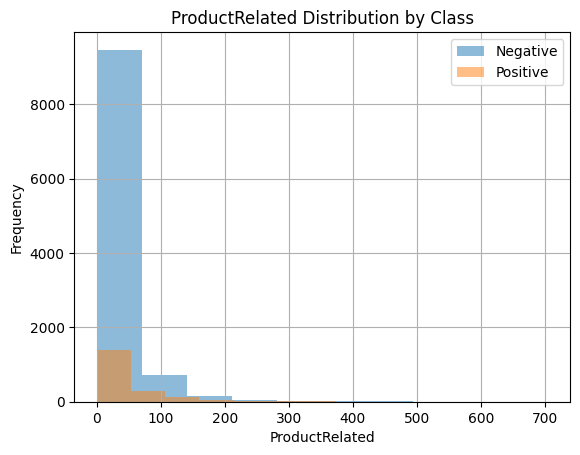

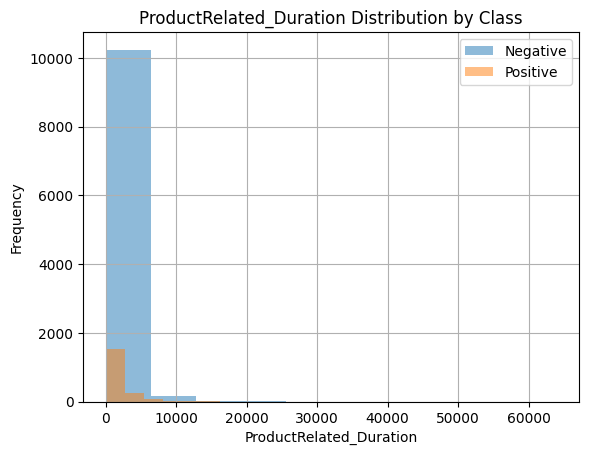

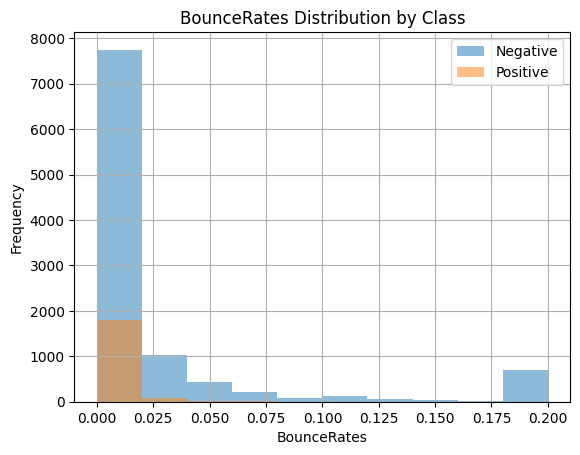

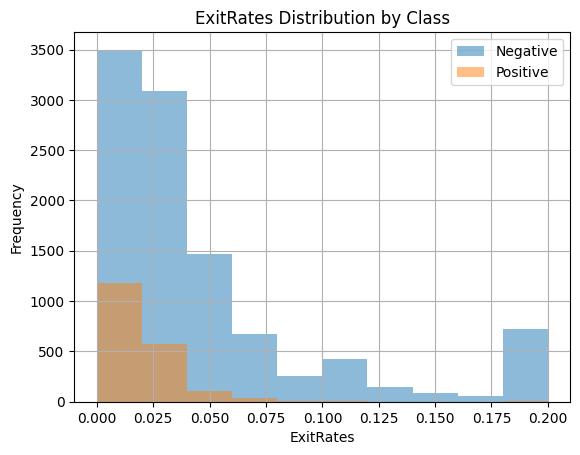

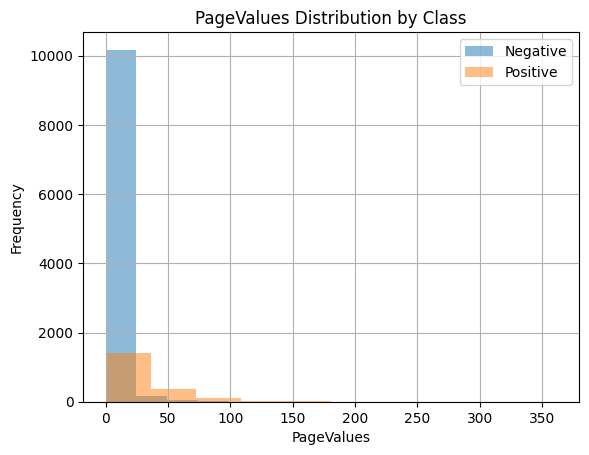

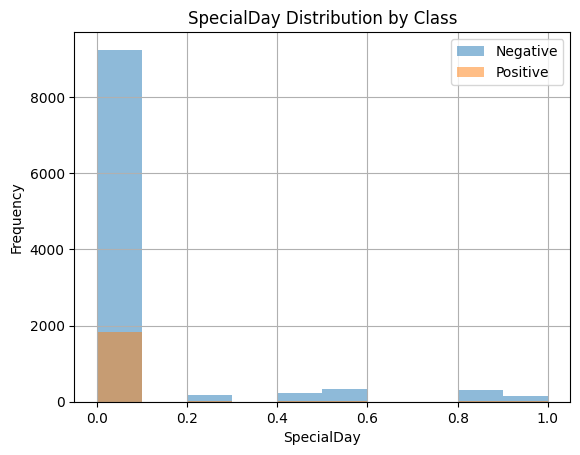

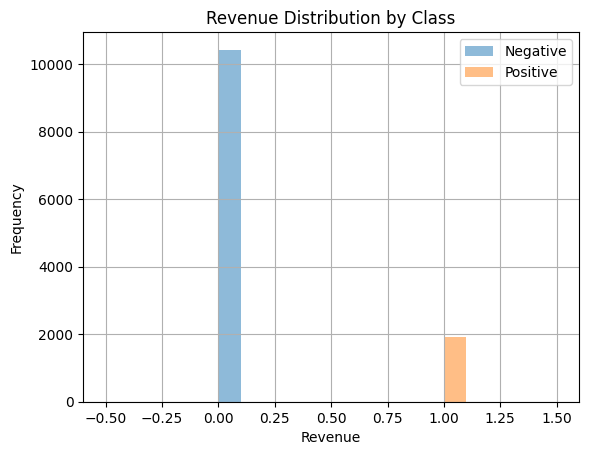

In [318]:
for col in num_cols:
    plt.figure()
    
    data[data['Revenue'] == False][col].hist(alpha=0.5, label='Negative')
    data[data['Revenue'] == True][col].hist(alpha=0.5, label='Positive')
    
    plt.title(f'{col} Distribution by Class')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    
    plt.show()

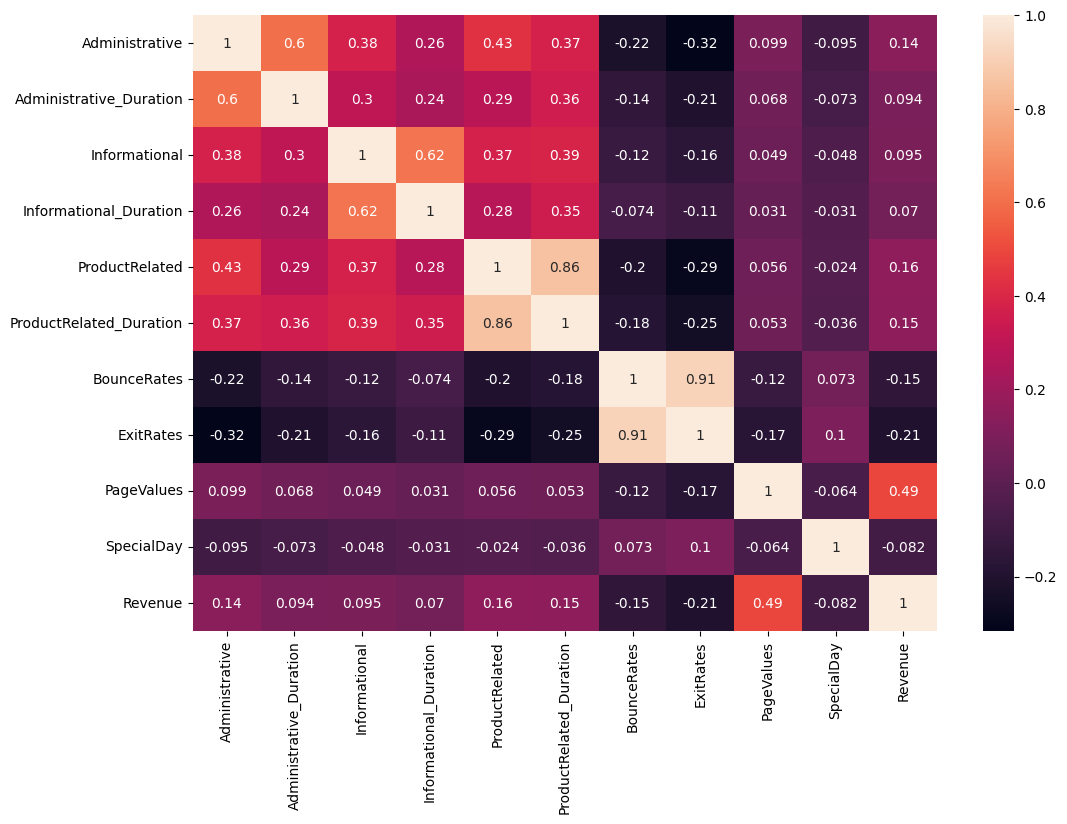

In [319]:
corr = data[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True)
plt.show()

# Treniranje modela i rezultati

In [320]:
cat_cols = ['OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Month',
]

num_cols = ['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay'
]

cat_cols = ['OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Month'
]

num_cols = ['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Weekend'
]

In [321]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

In [322]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8453636117869695
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      3127
           1       0.00      0.00      0.00       572

    accuracy                           0.85      3699
   macro avg       0.42      0.50      0.46      3699
weighted avg       0.71      0.85      0.77      3699



/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [323]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), num_cols),
#         ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
#     ]
# )

# models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=200,
#         random_state=42,
#         n_jobs=-1
#     ),
#     "SVM Linear": SVC(
#         kernel="linear",
#         random_state=42
#     ),
#     "SVM RBF": SVC(
#         kernel="rbf",
#         random_state=42
#     )
# }

# sss = StratifiedShuffleSplit(
#     n_splits=1,
#     test_size=0.3,
#     random_state=42
# )

# results = {
#     model_name: {
#         "accuracy": [],
#         "precision": [],
#         "recall": [],
#         "f1": []
#     }
#     for model_name in models
# }

# for train_idx, val_idx in sss.split(X, y):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     for model_name, model in models.items():
#         pipeline = Pipeline([
#             ("preprocessing", preprocessor),
#             ("model", model)
#         ])

#         pipeline.fit(X_train, y_train)
#         y_pred = pipeline.predict(X_val)

#         results[model_name]["accuracy"].append(accuracy_score(y_val, y_pred))
#         results[model_name]["precision"].append(
#             precision_score(y_val, y_pred, zero_division=0)
#         )
#         results[model_name]["recall"].append(
#             recall_score(y_val, y_pred, zero_division=0)
#         )
#         results[model_name]["f1"].append(
#             f1_score(y_val, y_pred, zero_division=0)
#         )

# summary = []

# for model_name in models:
#     row = {"Model": model_name}
#     for metric in ["accuracy", "precision", "recall", "f1"]:
#         # row[f"{metric}_mean"] = np.mean(results[model_name][metric])
#         # row[f"{metric}_std"] = np.std(results[model_name][metric])
#         row[f"{metric}"] = np.mean(results[model_name][metric])
#     summary.append(row)

# summary_df = pd.DataFrame(summary)
# summary_df

In [324]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), num_cols),
#         ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
#     ]
# )

# models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=200,
#         random_state=42,
#         n_jobs=-1
#     ),
#     "SVM Linear": SVC(
#         kernel="linear",
#         random_state=42
#     ),
#     "SVM RBF": SVC(
#         kernel="rbf",
#         random_state=42
#     )
# }

# sss = StratifiedShuffleSplit(
#     n_splits=1,
#     test_size=0.3,
#     random_state=42
# )

# results = {
#     model_name: {
#         "accuracy": [],
#         "precision": [],
#         "recall": [],
#         "f1": []
#     }
#     for model_name in models
# }

# for split_id, (train_idx, val_idx) in enumerate(sss.split(X, y)):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     for model_name, model in models.items():
#         pipeline = Pipeline([
#             ("oversample", RandomOverSampler(random_state=42 + split_id)),
#             ("preprocessing", preprocessor),
#             ("model", model)
#         ])

#         pipeline.fit(X_train, y_train)
#         y_pred = pipeline.predict(X_val)

#         results[model_name]["accuracy"].append(accuracy_score(y_val, y_pred))
#         results[model_name]["precision"].append(
#             precision_score(y_val, y_pred, zero_division=0)
#         )
#         results[model_name]["recall"].append(
#             recall_score(y_val, y_pred, zero_division=0)
#         )
#         results[model_name]["f1"].append(
#             f1_score(y_val, y_pred, zero_division=0)
#         )

# summary = []

# for model_name in models:
#     row = {"Model": model_name}
#     for metric in ["accuracy", "precision", "recall", "f1"]:
#         row[f"{metric}"] = np.mean(results[model_name][metric])
#     summary.append(row)

# summary_df = pd.DataFrame(summary)
# summary_df

In [325]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), num_cols),
#         ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
#     ]
# )

# models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=100, # promenio sa 200
#         random_state=42,
#         n_jobs=-1
#     ),
#     "SVM Linear": SVC(
#         kernel="linear", 
#         random_state=42
#     ),
#     "SVM RBF": SVC(
#         kernel="rbf", 
#         random_state=42
#     )
# }

# modes = {
#     "No OS": None,
#     "With OS": RandomOverSampler
# }

# sss = StratifiedShuffleSplit(
#     n_splits=1,
#     test_size=0.3,
#     random_state=42
# )

# results = {}

# for mode in modes:
#     for model_name in models:
#         key = f"{model_name} | {mode}"
#         results[key] = {
#             "accuracy": [],
#             "precision": [],
#             "recall": [],
#             "f1": []
#         }

# for split_id, (train_idx, val_idx) in enumerate(sss.split(X, y)):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     for mode_name, sampler_class in modes.items():
#         for model_name, model in models.items():

#             steps = []

#             if sampler_class is not None:
#                 steps.append(
#                     ("oversample", sampler_class(random_state=42 + split_id))
#                 )

#             steps.append(("preprocessing", preprocessor))
#             steps.append(("model", model))

#             pipeline = Pipeline(steps)

#             pipeline.fit(X_train, y_train)
#             y_pred = pipeline.predict(X_val)

#             key = f"{model_name} | {mode_name}"

#             results[key]["accuracy"].append(
#                 accuracy_score(y_val, y_pred)
#             )
#             results[key]["precision"].append(
#                 precision_score(y_val, y_pred, zero_division=0)
#             )
#             results[key]["recall"].append(
#                 recall_score(y_val, y_pred, zero_division=0)
#             )
#             results[key]["f1"].append(
#                 f1_score(y_val, y_pred, zero_division=0)
#             )

# summary = []

# for key in results:
#     row = {"Model": key}
#     for metric in ["accuracy", "precision", "recall", "f1"]:
#         row[f"{metric}"] = np.mean(results[key][metric])
#     summary.append(row)

# summary_df = pd.DataFrame(summary)
# summary_df

In [326]:


# -------------------------------------------------------
# KORAK 1: Grid Search za SVM hiperparametre
# Radi se na JEDNOJ nasumičnoj particiji (kao u radu)
# -------------------------------------------------------

# # Jedna particija za grid search
# gss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
# train_idx_gs, val_idx_gs = next(gss.split(X, y))
# X_train_gs = X.iloc[train_idx_gs]
# y_train_gs = y.iloc[train_idx_gs]
# X_val_gs   = X.iloc[val_idx_gs]
# y_val_gs   = y.iloc[val_idx_gs]

# # Preprocessing za grid search (bez oversampla, samo na train setu)
# preprocessor_gs = ColumnTransformer(transformers=[
#     ("num", StandardScaler(), num_cols),
#     ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
# ])
# X_train_gs_proc = preprocessor_gs.fit_transform(X_train_gs)
# X_val_gs_proc   = preprocessor_gs.transform(X_val_gs)

# print("Tražim optimalne C i gamma za SVM (grid search)...")

# # Grid search za Linear SVM (samo C)
# param_grid_linear = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}
# gs_linear = GridSearchCV(
#     SVC(kernel="linear", random_state=42),
#     param_grid_linear,
#     scoring="f1",
#     cv=5,
#     n_jobs=-1
# )
# gs_linear.fit(X_train_gs_proc, y_train_gs)
# best_C_linear = gs_linear.best_params_["C"]
# print(f"  SVM Linear -> best C: {best_C_linear}")

# # Grid search za RBF SVM (C i gamma)
# param_grid_rbf = {
#     "C":     [0.001, 0.01, 0.1, 1, 10, 100],
#     "gamma": [0.001, 0.01, 0.1, 1, 10, 100]
# }
# gs_rbf = GridSearchCV(
#     SVC(kernel="rbf", random_state=42),
#     param_grid_rbf,
#     scoring="f1",
#     cv=5,
#     n_jobs=-1
# )
# gs_rbf.fit(X_train_gs_proc, y_train_gs)
# best_C_rbf    = gs_rbf.best_params_["C"]
# best_gamma    = gs_rbf.best_params_["gamma"]
# print(f"  SVM RBF   -> best C: {best_C_rbf}, best gamma: {best_gamma}")

# -------------------------------------------------------
# KORAK 2: Definisanje modela sa nađenim hiperparametrima
# -------------------------------------------------------
best_C_linear = 1
best_C_rbf = 100
best_gamma = 0.01

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,   # kao u radu
        random_state=42,
        n_jobs=-1
    ),
    "SVM Linear": SVC(
        kernel="linear",
        C=best_C_linear,    # iz grid searcha
        random_state=42
    ),
    "SVM RBF": SVC(
        kernel="rbf",
        C=best_C_rbf,       # iz grid searcha
        gamma=best_gamma,   # iz grid searcha
        random_state=42
    )
}

modes = {
    "No OS":   None,
    "With OS": RandomOverSampler
}

# -------------------------------------------------------
# KORAK 3: 100 nasumičnih particija (kao u radu)
# -------------------------------------------------------

N_SPLITS = 100  # kao u radu

sss = StratifiedShuffleSplit(
    n_splits=N_SPLITS,
    test_size=0.3,
    random_state=42
)

results = {}
for mode_name in modes:
    for model_name in models:
        results[f"{model_name} | {mode_name}"] = {
            "accuracy":  [],
            "precision": [],
            "recall":    [],
            "f1":        []
        }

print(f"\nPokrećem {N_SPLITS} iteracija...")

for split_id, (train_idx, val_idx) in enumerate(sss.split(X, y)):
    
    if (split_id + 1) % 10 == 0:
        print(f"  Split {split_id + 1}/{N_SPLITS}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    for mode_name, sampler_class in modes.items():
        for model_name, model in models.items():
            key = f"{model_name} | {mode_name}"

            steps = []
            if sampler_class is not None:
                # ImbPipeline podržava resamplere unutar pipeline-a
                # steps.append(("oversample", sampler_class(random_state=42 + split_id)))
                steps.append(("oversample", sampler_class(random_state=42)))
            steps.append(("preprocessing", preprocessor))
            steps.append(("model", model))

            pipeline = Pipeline(steps)
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_val)

            results[key]["accuracy"].append(accuracy_score(y_val, y_pred))
            results[key]["precision"].append(precision_score(y_val, y_pred, zero_division=0))
            results[key]["recall"].append(recall_score(y_val, y_pred, zero_division=0))
            results[key]["f1"].append(f1_score(y_val, y_pred, zero_division=0))

# -------------------------------------------------------
# KORAK 4: Sumiranje rezultata
# -------------------------------------------------------

summary = []
for key, metrics in results.items():
    model_part, mode_part = key.split(" | ")
    row = {
        "Model":     model_part,
        "Mode":      mode_part,
        "Accuracy":  round(np.mean(metrics["accuracy"])  * 100, 2),
        "Precision": round(np.mean(metrics["precision"]), 4),
        "Recall":    round(np.mean(metrics["recall"]),    4),
        "F1 Score":  round(np.mean(metrics["f1"]),        4),
    }
    summary.append(row)

summary_df = pd.DataFrame(summary)

# Prikaz odvojeno po modu radi preglednosti
print("\n=== Rezultati BEZ oversampla ===")
print(summary_df[summary_df["Mode"] == "No OS"].to_string(index=False))

print("\n=== Rezultati SA oversampleom ===")
print(summary_df[summary_df["Mode"] == "With OS"].to_string(index=False))

summary_df


Pokrećem 100 iteracija...


/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning

  Split 10/100


/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning

  Split 20/100


...

/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning

  Split 100/100


/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning


=== Rezultati BEZ oversampla ===
        Model  Mode  Accuracy  Precision  Recall  F1 Score
Random Forest No OS     90.08     0.7659  0.5168    0.6169
   SVM Linear No OS     88.54     0.7446  0.3948    0.5156
      SVM RBF No OS     89.35     0.7133  0.5212    0.6020

=== Rezultati SA oversampleom ===
        Model    Mode  Accuracy  Precision  Recall  F1 Score
Random Forest With OS     89.95     0.6904  0.6360    0.6618
   SVM Linear With OS     87.33     0.5684  0.7550    0.6483
      SVM RBF With OS     85.43     0.5209  0.7278    0.6070


,Model,Mode,Accuracy,Precision,Recall,F1 Score
0,Random Forest,No OS,90.08,0.7659,0.5168,0.6169
1,SVM Linear,No OS,88.54,0.7446,0.3948,0.5156
2,SVM RBF,No OS,89.35,0.7133,0.5212,0.6020
3,Random Forest,With OS,89.95,0.6904,0.6360,0.6618
4,SVM Linear,With OS,87.33,0.5684,0.7550,0.6483
5,SVM RBF,With OS,85.43,0.5209,0.7278,0.6070


In [331]:
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, val_idx = next(sss_test.split(X, y))
X_train_t, y_train_t = X.iloc[train_idx], y.iloc[train_idx]
X_val_t, y_val_t = X.iloc[val_idx], y.iloc[val_idx]

prep_test = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])
X_train_proc = prep_test.fit_transform(X_train_t)
X_val_proc = prep_test.transform(X_val_t)

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train_proc, y_train_t)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)
y_pred = rf.predict(X_val_proc)

print("F1 binary:", f1_score(y_val_t, y_pred, average='binary'))
print("F1 macro:", f1_score(y_val_t, y_pred, average='macro'))
print("F1 weighted:", f1_score(y_val_t, y_pred, average='weighted'))

/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/vuk/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


F1 binary: 0.6386554621848739
F1 macro: 0.7887445162986959
F1 weighted: 0.8924151119355748


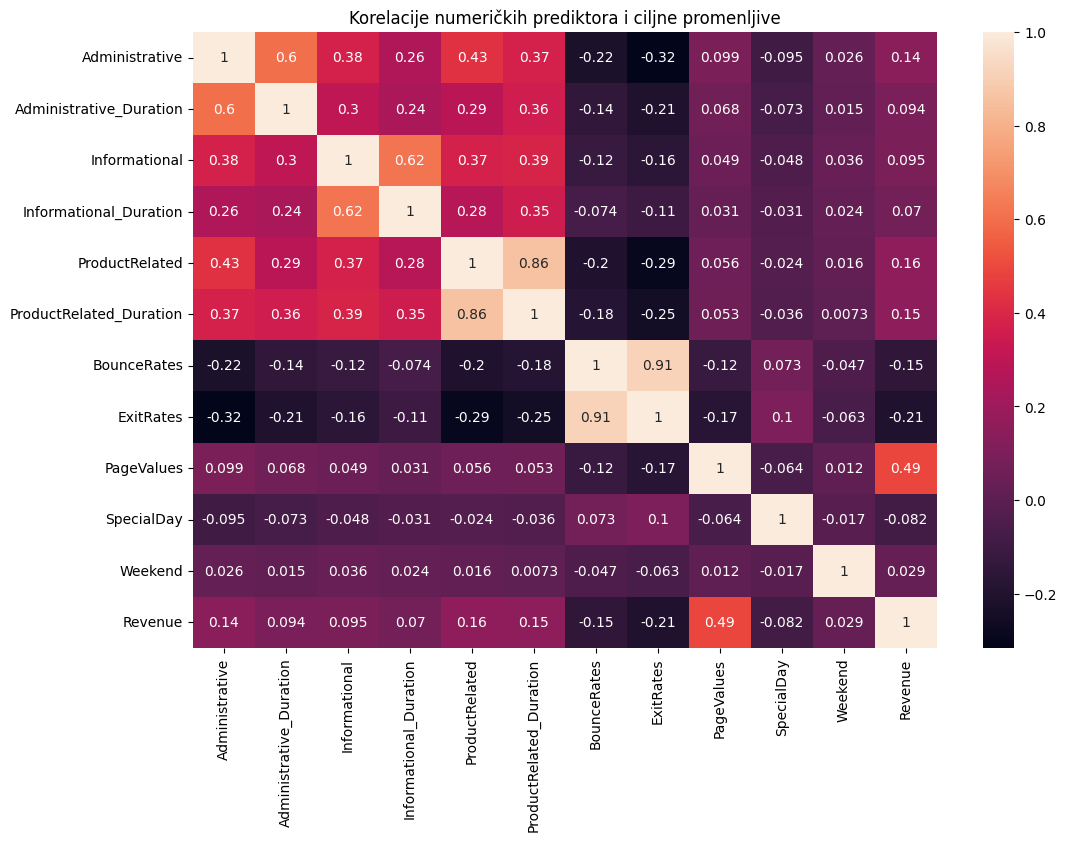

In [333]:
num_cols.append('Revenue')
corr = data[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True)
plt.title('Korelacije numeričkih prediktora i ciljne promenljive')
plt.show()